# Predictive Analytics: Support Vector Machine (SVM)

This notebook implements a complete machine learning pipeline using **Support Vector Regression (SVR)** to predict taxi trip demand in Chicago under various spatio-temporal resolutions.

In [1]:
import pandas as pd
import numpy as np
import h3
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
from pathlib import Path
from sklearn.svm import SVR, LinearSVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
## Import the data-splits:
df_train = pd.read_parquet("../data/df_train.parquet")
df_val = pd.read_parquet("../data/df_val.parquet")
df_test = pd.read_parquet("../data/df_test.parquet")
print(f"Train split loaded. Shape: {df_train.shape}")
print(f"Validation split loaded. Shape: {df_val.shape}")
print(f"Test split loaded. Shape: {df_test.shape}")

Loading final grid dataset...


Final grid loaded. Shape: (9272950, 36)


In [ ]:
# DEFINE TARGET AND FEATURES
target = 'Total_Trip_Starts'  # Assuming this is the target variable in the dataset

# Select final features and target column
features = [
    'distance_to_loop',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'is_weekend', 'is_holiday', 'day_of_week',
    'poi_cat_automotive', 'poi_cat_civic_community', 'poi_cat_education',
    'poi_cat_entertainment', 'poi_cat_finance', 'poi_cat_food_drink',
    'poi_cat_grocery', 'poi_cat_health', 'poi_cat_leisure_sports',
    'poi_cat_lodging', 'poi_cat_nightlife', 'poi_cat_services','poi_cat_shopping', 'poi_cat_transport'
]

# Scaling
scaler = StandardScaler()
scaler.fit(df_train[features])

X_train = scaler.transform(df_train[features])
y_train = df_train['Total_Trip_Start'].values

X_val = scaler.transform(df_val[features])
y_val = df_val['Total_Trip_Start'].values

X_test = scaler.transform(df_test[features])
y_test = df_test['Total_Trip_Start'].values

# ── SVM subsample (SVR scales poorly with large datasets) ────────────────────

svm_sample = df_train.sample(n=10000, random_state=42)
X_train_svm = scaler.transform(svm_sample[features])
y_train_svm = svm_sample['Total_Trip_Start'].values

**Kernel Comparison**: Train SVR models starting with a Linear kernel (equivalent to no kernel) and progressively introduce Polynomial and RBF kernels.

In [6]:
KERNELS = ['linear','poly','rbf']
models_results = {}
kernel_r2 = {}  # raw kernel name -> R², so we can recover the actual kernel later

for kernel in KERNELS:
    print(f"Training SVR with {kernel} kernel...")
    svr = SVR(kernel=kernel)
    svr.fit(X_train, y_train)
    print(f"Predicting with SVR ({kernel})...")
    y_pred = svr.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"SVR ({kernel}) - MAE: {mae:.2f}, MSE: {mse:.2f}, R²: {r2:.4f}")
    models_results[f'SVR ({kernel})'] = y_pred
    kernel_r2[kernel] = r2

# Pick the best by R² and keep the RAW kernel name (e.g. 'poly'), not the display
# label 'SVR (poly)', so it can be passed straight to SVR(kernel=...).
best_kernel = max(kernel_r2, key=kernel_r2.get)
print(f"Best SVR kernel based on R²: {best_kernel}")

Training SVR with linear kernel...


Predicting with SVR (linear)...


SVR (linear) - MAE: 0.72, MSE: 39.19, R²: 0.0447
Training SVR with poly kernel...


Predicting with SVR (poly)...


SVR (poly) - MAE: 0.52, MSE: 16.29, R²: 0.6029
Training SVR with rbf kernel...


Predicting with SVR (rbf)...


SVR (rbf) - MAE: 0.66, MSE: 36.36, R²: 0.1138
Best SVR kernel based on R²: poly


**Hyperparameter Grid Search**: Optimize the `C` and `gamma` hyperparameters for RBF SVR via grid search.

In [7]:
# Grid Search Optimization on best kernel
print("Running GridSearchCV on " + best_kernel + " SVR on a smaller sample (5000 rows)...")
X_grid_sample = X_train[:5000]
y_grid_sample = y_train[:5000]

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.1]
}

grid_search = GridSearchCV(SVR(kernel=best_kernel, max_iter=10000), param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_search.fit(X_grid_sample, y_grid_sample)
best_svr = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

y_pred_opt = best_svr.predict(X_test)
models_results['Optimized ' + best_kernel] = y_pred_opt

Running GridSearchCV on poly SVR on a smaller sample (5000 rows)...


/Users/tjorgeorlitz/Documents/Uni/Semester 2/AAA/Project/AAA_Project_Group7/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/tjorgeorlitz/Documents/Uni/Semester 2/AAA/Project/AAA_Project_Group7/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/tjorgeorlitz/Documents/Uni/Semester 2/AAA/Project/AAA_Project_Group7/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/tjorgeorlitz/Documents/Uni/Semester 2/AAA/Project/AAA_Project_Group7/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:340:

/Users/tjorgeorlitz/Documents/Uni/Semester 2/AAA/Project/AAA_Project_Group7/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/tjorgeorlitz/Documents/Uni/Semester 2/AAA/Project/AAA_Project_Group7/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/tjorgeorlitz/Documents/Uni/Semester 2/AAA/Project/AAA_Project_Group7/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/tjorgeorlitz/Documents/Uni/Semester 2/AAA/Project/AAA_Project_Group7/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:340:

/Users/tjorgeorlitz/Documents/Uni/Semester 2/AAA/Project/AAA_Project_Group7/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/tjorgeorlitz/Documents/Uni/Semester 2/AAA/Project/AAA_Project_Group7/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/tjorgeorlitz/Documents/Uni/Semester 2/AAA/Project/AAA_Project_Group7/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Best Parameters: {'C': 10, 'gamma': 0.01}


**Model Evaluation**:


--- Model Performance Comparison ---
         Model      MAE     RMSE       R2
  SVR (linear) 0.651860 6.259312 0.045081
    SVR (poly) 0.464496 4.005474 0.608960
     SVR (rbf) 0.649423 6.029733 0.113845
Optimized poly 0.548599 4.638698 0.475548


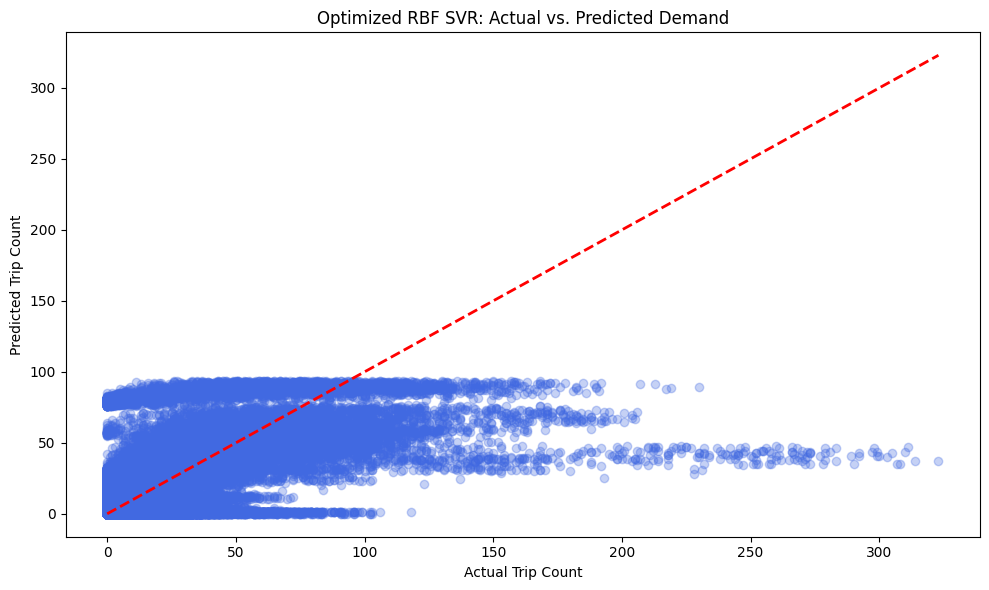

In [8]:

evaluation_metrics = []
for name, preds in models_results.items():
    # SVR predicts continuous values, clip predicted demand at 0
    clipped_preds = np.clip(preds, 0, None)
    mae = mean_absolute_error(y_test, clipped_preds)
    rmse = np.sqrt(mean_squared_error(y_test, clipped_preds))
    r2 = r2_score(y_test, clipped_preds)
    evaluation_metrics.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

df_metrics = pd.DataFrame(evaluation_metrics)
print("\n--- Model Performance Comparison ---")
print(df_metrics.to_string(index=False))

# Plot actual vs predicted values for RBF SVR
plt.figure(figsize=(10, 6))
plt.scatter(y_test, np.clip(y_pred_opt, 0, None), alpha=0.3, color='royalblue')
plt.plot([0, y_test.max()], [0, y_test.max()], 'r--', lw=2)
plt.title("Optimized RBF SVR: Actual vs. Predicted Demand")
plt.xlabel("Actual Trip Count")
plt.ylabel("Predicted Trip Count")
plt.tight_layout()
plt.show()

## Spatial Prediction Quality: Which Hexagons Are Predicted Well?

The aggregate metrics above collapse the whole city into a single number and hide
strong **spatial** variation in how well the model performs. Here we attach the
optimized SVR predictions back to each test observation, aggregate the error by
H3 cell, and map it. Two complementary views answer "where does the model work?":

- **MAE per hexagon** — the absolute size of the prediction miss (trips/hour).
- **R² per hexagon** — how much of each cell's hour-to-hour demand *variation* the
  model explains. Cells whose demand is essentially flat (the quiet outskirts)
  have no variation to explain, so their R² is undefined and they are greyed out.

In [9]:
# --- Spatial visualisation setup ---------------------------------------------
import geopandas as gpd
import contextily as ctx
import shapely

# Community area outlines, used as a spatial reference overlay in the choropleths.
community_areas = gpd.read_file(Path('..') / 'data' / 'chicago_community_areas.gpkg')


def get_hexagon_grid(data, h3_col='h3_index'):
    """
    Build a GeoDataFrame of H3 hexagon polygons, preserving all columns from the source.

    Parameters
    ----------
    data : pd.DataFrame or pd.Series
        Source data. If DataFrame, all columns are kept in the output.
        If Series, the output has only 'h3_index' and 'geometry'.
    h3_col : str
        Column in `data` containing H3 cell IDs (ignored when data is a Series).

    Returns
    -------
    GeoDataFrame with all original columns plus 'geometry', CRS EPSG:4326.
    """
    def _to_polygon(cell):
        boundary = h3.cell_to_boundary(cell)
        return shapely.geometry.Polygon([(lng, lat) for lat, lng in boundary])

    if isinstance(data, pd.Series):
        h3_list = list(data)
        df = pd.DataFrame({'h3_index': h3_list})
    else:
        h3_list = list(data[h3_col])
        df = data.reset_index(drop=True)

    geometries = [_to_polygon(cell) for cell in h3_list]
    return gpd.GeoDataFrame(df, geometry=geometries, crs='EPSG:4326')


def create_choropleth_plot(
    gdf,
    value_col='poi_count',
    title='POI count per H3 hexagon',
    boundaries=None,
    cmap='YlOrRd',
    figsize=(6, 8),
    k=7,
):
    """
    Create a static matplotlib choropleth of hexagon values with Chicago basemap.

    Parameters
    ----------
    gdf : GeoDataFrame
        Must contain 'geometry' and `value_col`. CRS EPSG:4326.
    value_col : str
        Column used to colour hexagons.
    title : str
        Figure title.
    boundaries : GeoDataFrame or None
        Community area outlines to overlay. Defaults to the global `community_areas`.
    cmap : str
        Matplotlib colour map name.
    figsize : tuple
        Figure size in inches.
    k : int
        Number of quantile classes for the colour scheme.

    Returns
    -------
    fig, ax
    """
    if boundaries is None:
        boundaries = community_areas

    fig, ax = plt.subplots(figsize=figsize)

    gdf_web = gdf.to_crs(epsg=3857)
    gdf_web.plot(
        ax=ax,
        column=value_col,
        cmap=cmap,
        scheme='quantiles',
        k=k,
        edgecolor='none',
        alpha=0.8,
        legend=True,
        zorder=1,
        legend_kwds=dict(
            title=value_col.replace('_', ' ').title(),
            loc='lower right',
            fontsize=8,
            title_fontsize=9,
        ),
        missing_kwds=dict(color='lightgrey', label='No data'),
    )

    # Basemap underneath everything
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, zoom=11)

    # Community area outlines drawn last so they sit on top of basemap and hexagons
    boundaries.to_crs(epsg=3857).boundary.plot(
        ax=ax, color='#222', linewidth=1.0, alpha=0.9, zorder=3,
    )

    ax.set_axis_off()
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    plt.tight_layout()
    return fig, ax

In [63]:
#| label: tbl-svm-hex-performance
# Attach the optimized SVR predictions back onto their test rows so prediction
# quality can be measured per H3 cell (spatially) rather than only globally.
df_eval = df_test[['h3_index', 'Total_Trip_Start']].copy()
df_eval['y_pred'] = np.clip(y_pred_opt, 0, None)   # same clipping used in evaluation
df_eval['abs_err'] = (df_eval['Total_Trip_Start'] - df_eval['y_pred']).abs()
df_eval['sq_err'] = (df_eval['Total_Trip_Start'] - df_eval['y_pred']) ** 2

grp = df_eval.groupby('h3_index')
hex_perf = grp.agg(
    n_obs=('Total_Trip_Start', 'size'),
    mean_actual=('Total_Trip_Start', 'mean'),
    var_actual=('Total_Trip_Start', 'var'),   # sample variance (ddof=1)
    mae=('abs_err', 'mean'),
    mse=('sq_err', 'mean'),
)
hex_perf['rmse'] = np.sqrt(hex_perf['mse'])

# R2 per hexagon: 1 - SS_res / SS_tot. SS_tot = sample_var * (n - 1).
# Cells with no demand variation (SS_tot == 0) get NaN -> shown grey on the map.
ss_res = grp['sq_err'].sum()
ss_tot = hex_perf['var_actual'].fillna(0) * (hex_perf['n_obs'] - 1)
hex_perf['r2'] = 1 - ss_res / ss_tot.replace(0, np.nan)

# Mean relative error per hexagon (WAPE-style): MAE as a fraction of the cell's
# own mean demand. A row-wise |y-yhat|/y is undefined for the many zero-demand
# observations, so we normalise the aggregated error by mean demand instead.
# NaN where the cell has no demand (mean_actual == 0).
hex_perf['rel_error'] = hex_perf['mae'] / hex_perf['mean_actual'].replace(0, np.nan)

hex_perf = hex_perf.drop(columns=['var_actual', 'mse']).reset_index()

# Build hexagon polygons once; reused by both choropleths below.
hex_perf_gdf = get_hexagon_grid(hex_perf, h3_col='h3_index')

n_scored = hex_perf['r2'].notna().sum()
print(f"{len(hex_perf)} hexagons evaluated; {n_scored} have enough demand variation for an R² score.")
print("\nBest-predicted cells (highest R²):")
print(hex_perf.nlargest(5, 'r2')[['h3_index', 'n_obs', 'mean_actual', 'mae', 'rmse', 'rel_error', 'r2']].to_string(index=False))
print("\nWorst-predicted cells with real demand (lowest R², mean_actual > 1):")
print(hex_perf[hex_perf['mean_actual'] > 1].nsmallest(5, 'r2')[['h3_index', 'n_obs', 'mean_actual', 'mae', 'rmse', 'rel_error', 'r2']].to_string(index=False))

454 hexagons evaluated; 225 have enough demand variation for an R² score.

Best-predicted cells (highest R²):
       h3_index  n_obs  mean_actual       mae      rmse  rel_error       r2
882664c1e1fffff   4081    29.382504 12.685142 17.870355   0.431724 0.603126
882664c1a9fffff   4081    35.101936 17.082595 28.103359   0.486657 0.560552
882664c1e3fffff   4081    41.921588 20.629586 28.430831   0.492099 0.473212
882664c1adfffff   4081    39.678265 29.419117 50.035959   0.741442 0.159054
882664c1a7fffff   4081     1.059299  0.965330  1.907859   0.911291 0.150375

Worst-predicted cells with real demand (lowest R², mean_actual > 1):
       h3_index  n_obs  mean_actual       mae      rmse  rel_error        r2
882664c1e7fffff   4081     6.725557  7.663914 10.655724   1.139521 -0.895143
88275934edfffff   4081    44.342808 49.657403 56.027352   1.119852 -0.743731
882664c1e9fffff   4081     7.702279  7.429545 10.916263   0.964590 -0.733439
882664c1ebfffff   4081    19.839990 19.390992 29.516031 

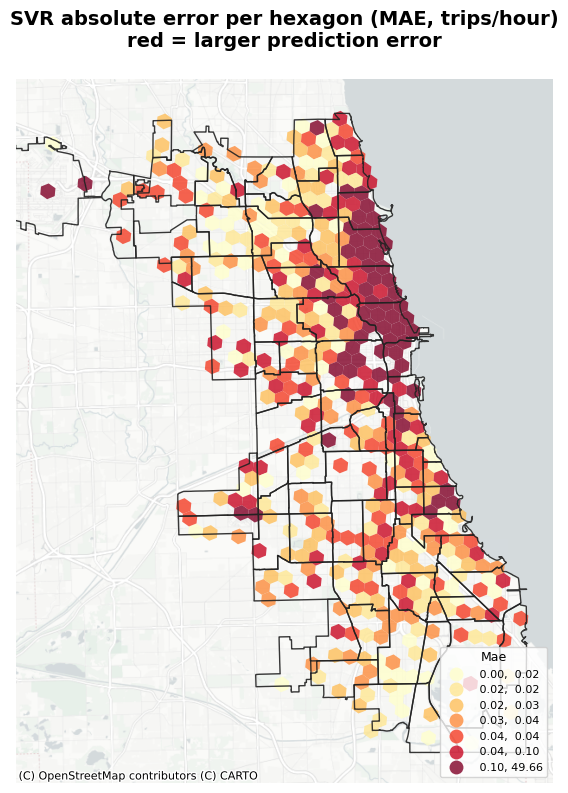

In [11]:
#| label: fig-svm-hex-mae
# Map 1: mean absolute error (MAE) per hexagon, in trips per hour.
# This is the absolute size of the prediction miss. Because demand itself is far
# higher downtown, the largest absolute errors concentrate in the Loop / O'Hare;
# the quiet outskirts have tiny MAE simply because there is little to predict.
fig, ax = create_choropleth_plot(
    hex_perf_gdf,
    value_col='mae',
    title='SVR absolute error per hexagon (MAE, trips/hour)\nred = larger prediction error',
    cmap='YlOrRd',
    k=7,
)
plt.show()

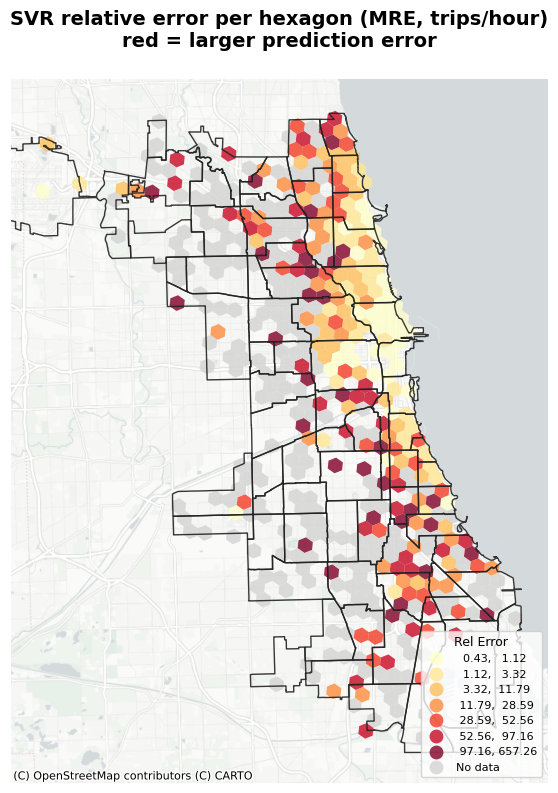

In [66]:
#| label: fig-svm-hex-mre
# Map 2: mean relative error (MRE) per hexagon, in trips per hour.
# This is the relative size of the prediction miss. Because demand itself is far
# higher downtown, the largest relative errors concentrate in the Loop / O'Hare;
# the quiet outskirts have tiny MRE simply because there is little to predict.
fig, ax = create_choropleth_plot(
    hex_perf_gdf,
    value_col='rel_error',
    title='SVR relative error per hexagon (MRE, trips/hour)\nred = larger prediction error',
    cmap='YlOrRd',
    k=7,
)
plt.show()

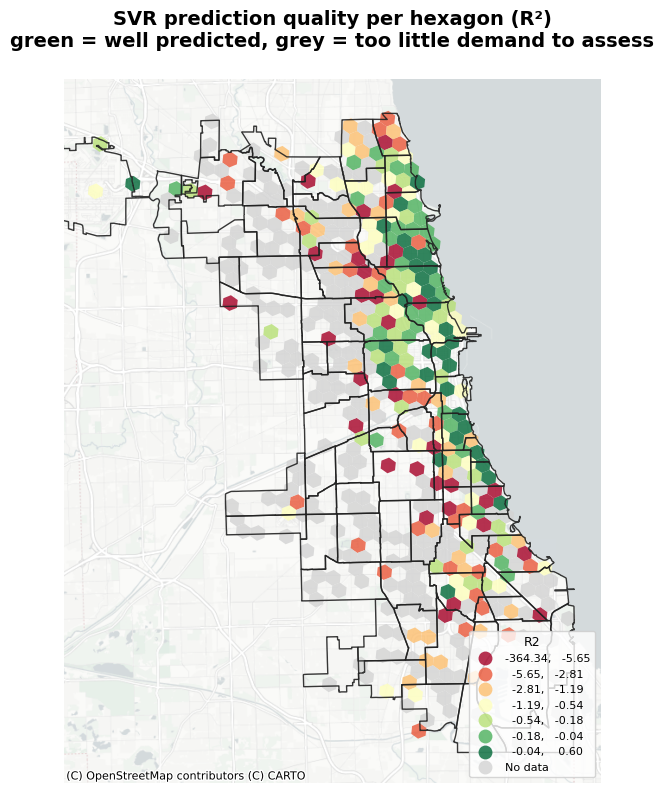

In [64]:
#| label: fig-svm-hex-r2
# Map 2: coefficient of determination (R2) per hexagon.
# R2 measures how much of each cell's hour-to-hour demand *variation* the model
# explains. Cells whose demand never moves (flat ~0 in the outskirts) have no
# variance to explain -> R2 is undefined and they are drawn grey ("No data").
# Green = the temporal demand pattern is captured well; red = poorly.
fig, ax = create_choropleth_plot(
    hex_perf_gdf,
    value_col='r2',
    title='SVR prediction quality per hexagon (R²)\ngreen = well predicted, grey = too little demand to assess',
    cmap='RdYlGn',
    k=7,
)
plt.show()

In [13]:
# TODO: Add Spatial and Temporal Resolution Analysis
# TODO: Spatial Resolution with Census Tracts
# TODO: Answering the "Outskirts Rainy Sunday" Scenario